# 02 — Clinical EDA: Demographics × Scar Geometry

Goal: characterise the patient population and look for associations between
demographic / clinical variables and MRI-derived scar metrics.

**Sections**
1. Dataset overview (completeness)
2. Demographics (age, sex, time MI→MRI)
3. Risk-factor prevalence
4. Scar geometry distributions
5. Echocardiography
6. Correlation heatmap
7. Subgroup box-plots
8. Outcomes preview

# CSV columns overview

This file looks like a **patient-level database**.  
Each **row = one patient**.  
The columns combine:

- identification data
- MRI scar measurements
- clinical history
- cardiac function
- arrhythmia data
- treatments
- follow-up outcomes
- medication

---

## 1. Identification and inclusion

- **ID**: patient identifier
- **FECHA IAM**: date of myocardial infarction
- **FECHA RM**: date of cardiac MRI
- **TIPO RM**: MRI type or quality note
- **DIAGNÓSTICO**: main diagnosis

---

## 2. MRI scar variables

- **LV MASS (g)**: left ventricular mass in grams
- **BZ + CORE (g)**: total scar mass in grams
- **BZ + CORE (%)**: total scar mass as percentage of LV mass
- **BZ (g)**: border zone mass in grams
- **BZ (%)**: border zone mass as percentage of LV mass
- **CORE (g)**: core scar mass in grams
- **CORE (%)**: core scar mass as percentage of LV mass
- **CHANNELS**: presence of channels in the scar
- **CHANNEL MASS (g)**: channel mass in grams
- **DISTRIBUCIÓN REALCE**: enhancement distribution
- **GRADO REALCE**: enhancement degree
- **TERRITORIO REALCE**: anatomical scar territory
- **@**: unclear column, probably an export artifact or empty field

---

## 3. Demographics and risk factors

- **FECHA NAC**: date of birth
- **EDAD**: age
- **SEXO**: sex
- **HTA**: hypertension
- **DLP**: dyslipidemia
- **DM**: diabetes mellitus
- **TABACO**: smoking
- **AFIB**: atrial fibrillation
- **NYHA**: NYHA functional class or heart failure status

---

## 4. Infarction and revascularization

- **IAM SÍ/NO**: previous myocardial infarction
- **FECHA IAM**: infarction date
- **FECHA REVASC**: revascularization date
- **TIPO REVASC**: type of revascularization
- **NOTAS REVASC**: revascularization notes

---

## 5. Cardiac structure and function

- **FEVI**: left ventricular ejection fraction
- **DTDVI**: LV end-diastolic diameter
- **DTSVI**: LV end-systolic diameter
- **VTDVI**: LV end-diastolic volume
- **VTDVIindex**: indexed LV end-diastolic volume
- **VTSVI**: LV end-systolic volume
- **VTSVIindex**: indexed LV end-systolic volume
- **AI**: left atrial size
- **SEPTO**: septal thickness
- **PARED POST**: posterior wall thickness

---

## 6. Devices

- **PORTADOR DISPOSITIVO**: presence of implanted device
- **FECHA IMPLANTE DISPOSITIVO**: implant date
- **TIPO DISPOSITIVO**: device type
- **TIPO PREVENCIÓN DAI**: ICD prevention type
- **BIOMONITOR**: monitor / rhythm device

---

## 7. Ventricular arrhythmias

- **AV CLÍNICAS**: clinical ventricular arrhythmias
- **FECHA AV CLÍNICA**: date of clinical VA
- **TIPO AV CLÍNICA**: type of clinical VA
- **SOO AV CLÍNICA**: probably site of origin of clinical VA
- **CARGA EV**: ventricular ectopic burden
- **NOTAS AV**: arrhythmia notes

- **AV INDUCIBLES**: inducible ventricular arrhythmias
- **FECHA EEF INDUCCIÓN**: date of EP induction study
- **TIPO AV INDUCIBLES**: type of inducible VA
- **SOO AV INDUCIBLE**: probably site of origin of inducible VA
- **TIPO CARDIOVERSIÓN AV INDUCIBLE**: type of cardioversion used

---

## 8. ICD therapies and ablation

- **TERAPIAS DAI**: ICD therapies delivered
- **FECHA TERAPIA DAI**: date of ICD therapy
- **TIPO TERAPIA DAI**: type of ICD therapy
- **ABLACIÓN AV**: ventricular arrhythmia ablation
- **FECHA ABLACIÓN**: ablation date
- **NOTAS ABLACIÓN**: ablation notes
- **OTRAS NOTAS**: other notes

---

## 9. Follow-up outcomes

- **6 MONTHS FOLLOW-UP DATE**: follow-up date
- **ADMISSION FOR HEART FAILURE**: heart failure admission
- **ADMISSION FOR ANGINA**: angina admission
- **REVASC. (Y/N)**: revascularization during follow-up
- **CLINICAL VA (Y/N)**: clinical ventricular arrhythmia during follow-up
- **CLINICAL VA DATE**: date of follow-up VA
- **CLINICAL VA TYPE**: type of follow-up VA
- **CLINICAL VA NOTES**: notes
- **DEATH (Y/N)**: death during follow-up
- **CARDIAC DEATH (Y/N)**: cardiac death
- **ARRHYTHMIC DEATH (Y/N)**: arrhythmic death
- **DEATH DATE**: date of death

---

## 10. Medication

- **IECAS (Y/N) + DOSE**: ACE inhibitor and dose
- **ARA 2 (Y/N) + DOSE**: ARB and dose
- **BETA-BLOCKERS + DOSE**: beta-blocker and dose
- **SPIRONOLACTONE (Y/N) + DOSE**: spironolactone and dose
- **FUROSEMIDE (Y/N)**: furosemide
- **DIGOXIN (Y/N)**: digoxin
- **AMIODARONE (Y/N)**: amiodarone or antiarrhythmic treatment
- **NYHA CLASS**: NYHA class

---

## Notes

Some columns are still uncertain and should be checked directly in the CSV, especially:

- **SEXO**
- **TIPO REVASC**
- **DISTRIBUCIÓN REALCE**
- **GRADO REALCE**
- **SOO AV CLÍNICA**
- **SOO AV INDUCIBLE**
- **@**

Also, many fields probably use binary coding:

- **0 = no**
- **1 = yes**

but this should be confirmed from the data.


In [30]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats as stats

# -- paths -----------------------------------------------------------------
# clinical_data.py lives in lv-scar-segmentation/; support launching from
# either the notebooks/ folder or the repo root.
cwd = Path.cwd().resolve()
if (cwd / "clinical_data.py").exists():
    MODULE_DIR = cwd
elif (cwd.parent / "clinical_data.py").exists():
    MODULE_DIR = cwd.parent
else:
    MODULE_DIR = Path("..").resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from clinical_data import load, COLUMN_GROUPS, summary, available_columns

# CSV registry
# Keep the dataset local: optionally point CLINICAL_CSV_PATH to your local
# file, otherwise this notebook falls back to the current local path.
CSV_PATH = Path(os.environ.get(
    "CLINICAL_CSV_PATH",
    r"C:\Users\joan\Desktop\FEINA\UPF\TFG\develop-vt.csv",
)).expanduser()

RESULTS_DIR = MODULE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)


def has_valid_linear_relation_data(df, x_col, y_col):
    """Return True when correlation/regression can be computed safely."""
    sub = df[[x_col, y_col]].dropna()
    return len(sub) >= 2 and sub[x_col].nunique() > 1 and sub[y_col].nunique() > 1


def ensure_2d_axes(axes, n_rows, n_cols):
    """Normalise matplotlib axes output to a 2D array."""
    return np.array(axes, dtype=object).reshape(n_rows, n_cols)


COLUMN_LABELS = {
    "age": "Age",
    "sex": "Sex",
    "hta": "Hypertension",
    "dlp": "Dyslipidaemia",
    "dm": "Diabetes",
    "smoking": "Smoking",
    "afib": "Atrial fibrillation",
    "mi_yn": "Prior MI",
    "nyha": "NYHA class",
    "lv_mass_g": "LV mass (g)",
    "core_g": "Core scar (g)",
    "core_pct": "Core scar (%)",
    "bz_g": "Border zone (g)",
    "bz_pct": "Border zone (%)",
    "bz_core_g": "BZ + core (g)",
    "bz_core_pct": "BZ + core (%)",
    "channel_mass_g": "Channel mass (g)",
    "channels": "Channels",
    "enhancement_territory": "Enhancement territory",
    "enhancement_distribution": "Enhancement distribution",
    "enhancement_grade": "Enhancement grade",
    "mri_type": "MRI type",
    "lvef_pct": "LVEF (%)",
    "lvedv_ml": "LVEDV (mL)",
    "lvesv_ml": "LVESV (mL)",
}


def pretty_label(col):
    return COLUMN_LABELS.get(col, col.replace("_", " ").title())


def clean_category_label(col, value):
    if pd.isna(value):
        return "Missing"
    if col == "channels":
        mapping = {0: "Absent", 1: "Present"}
        return mapping.get(value, str(value))
    if col == "sex":
        mapping = {1: "Male", 2: "Female"}
        return mapping.get(value, f"Unknown ({value})")
    return str(value)


def iqr_inlier_mask(s):
    s = s.dropna()
    if len(s) < 4:
        return pd.Series(True, index=s.index)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(True, index=s.index)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (s >= lower) & (s <= upper)

# -- style -----------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
CMAP = "Blues"
PAL  = plt.cm.tab10.colors


## 1 · Dataset overview

In [31]:
df = load(CSV_PATH)
print(f"Rows: {len(df)}   Columns: {len(df.columns)}")
summary(df)

Rows: 173   Columns: 86
=== Clinical registry: 173 patients ===

Completeness by column group:
  demographics          4 cols   66.2% non-null
  risk_factors          7 cols   44.2% non-null
  scar_geometry        12 cols   82.9% non-null
  echo                 10 cols   50.7% non-null
  devices               5 cols   28.2% non-null
  arrhythmias          11 cols   23.4% non-null
  followup             12 cols   19.5% non-null
  medications           7 cols   26.6% non-null
  mri_session           3 cols   88.1% non-null

Demographics:
  Age          mean=63.8  sd=10.4  [31–84]
  Sex (raw)    {np.int64(1): np.int64(80), <NA>: np.int64(78), np.int64(2): np.int64(15)}

Scar geometry (non-null patients):
        lv_mass_g   bz_core_g  bz_core_pct      core_g    core_pct        bz_g      bz_pct
count  166.000000  166.000000   166.000000  166.000000  166.000000  166.000000  166.000000
mean   120.239096   16.636566    13.048976    2.326024    1.812530   14.333735   11.253072
std     36.82291

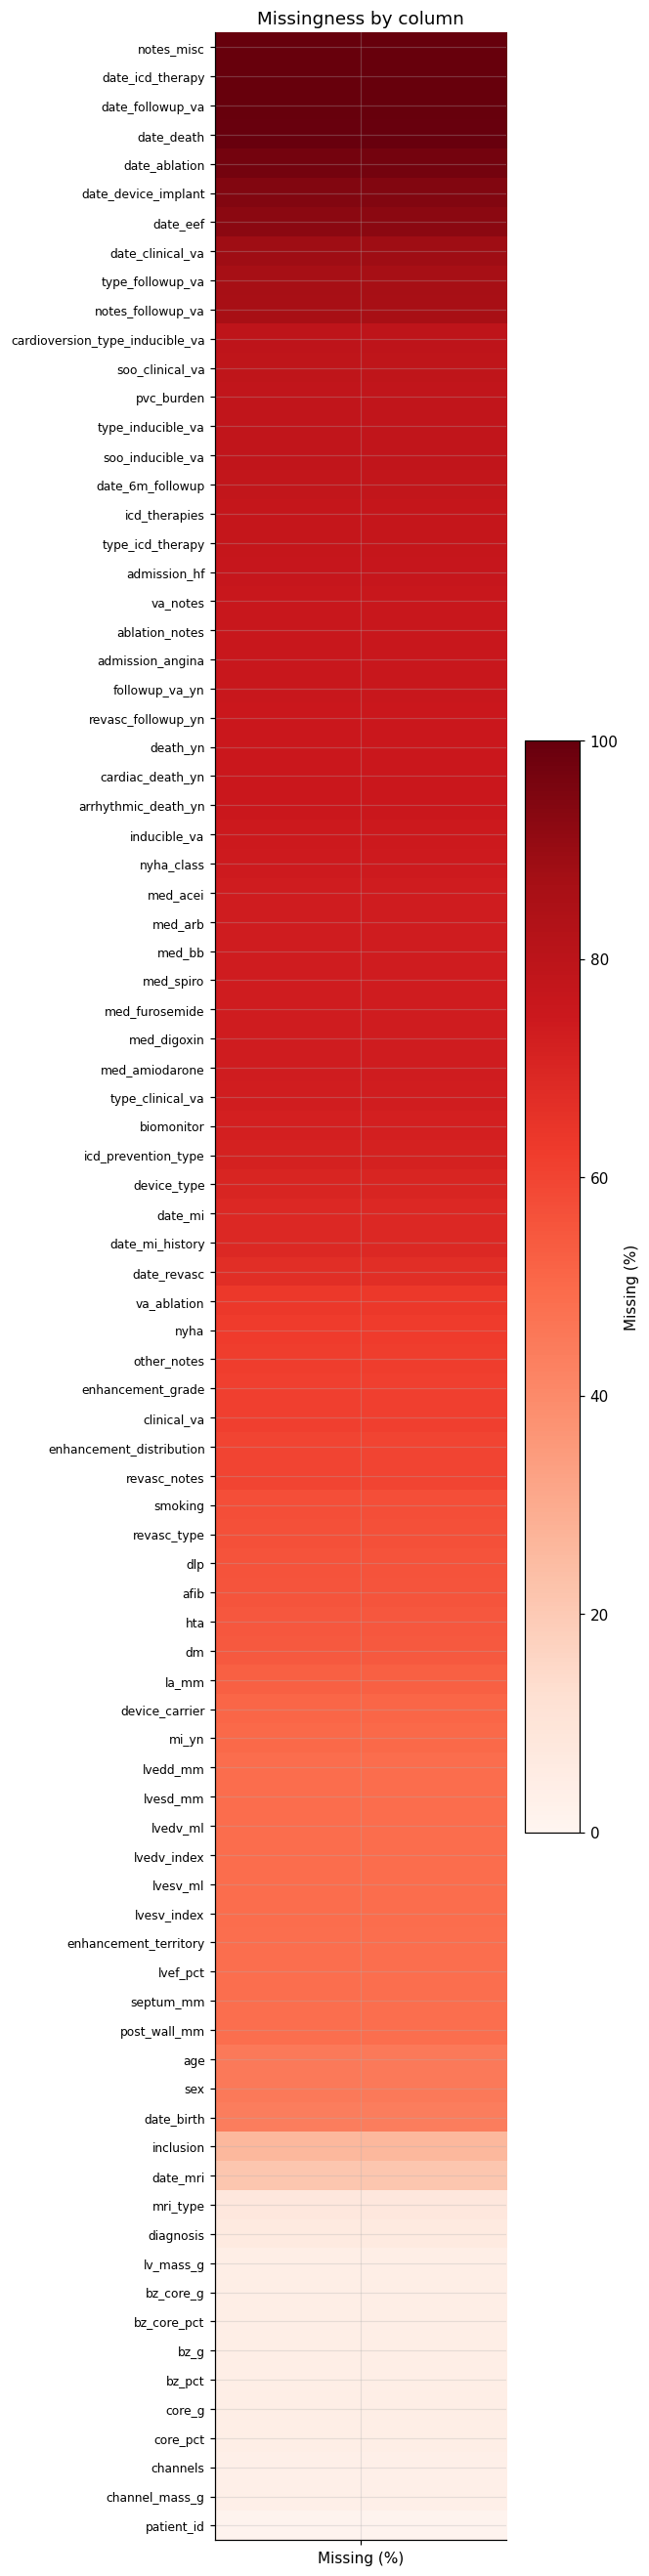


Columns with the most missing data:


,column,missing_n,missing_pct
0,notes_misc,173,100.000000
1,date_icd_therapy,173,100.000000
2,date_followup_va,173,100.000000
3,date_death,172,99.421965
4,date_ablation,168,97.109827
5,date_device_implant,163,94.219653
6,date_eef,160,92.485549
7,date_clinical_va,153,88.439306
8,type_followup_va,150,86.705202
9,notes_followup_va,149,86.127168


In [32]:
# ── Completeness heat-map ──────────────────────────────────────────────────
missing = (
    pd.DataFrame({
        "column": df.columns,
        "missing_n": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100),
    })
    .sort_values(["missing_pct", "missing_n"], ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, max(8, 0.28 * len(missing))))
bars = ax.barh(missing["column"], missing["missing_pct"], color="lightgray", edgecolor="dimgray")
for bar, pct, n in zip(bars, missing["missing_pct"], missing["missing_n"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n)})", va="center", fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Missing values (%)")
ax.set_xlim(0, min(115, max(105, missing["missing_pct"].max() + 12)))
ax.set_title("Missingness by column")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_completeness.png", bbox_inches="tight")
plt.show()

print("\nColumns with the most missing data:")
display(missing.head(15))

## 2 · Demographics

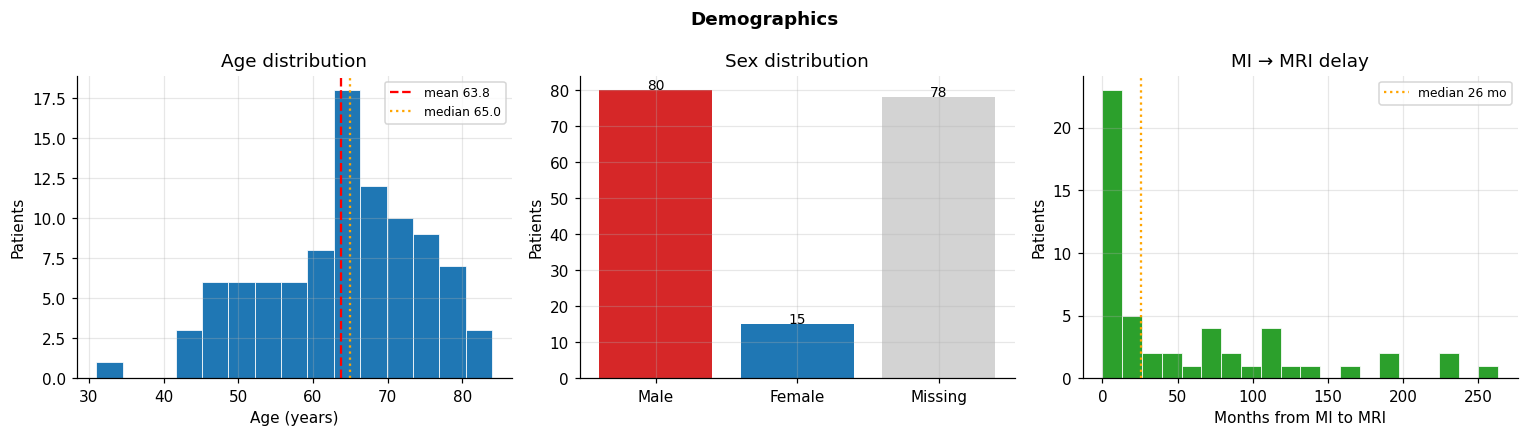

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# -- Age distribution -------------------------------------------------------
ax = axes[0]
age = df["age"].dropna()
ax.hist(age, bins=15, color=PAL[0], edgecolor="white", linewidth=0.5)
ax.axvline(age.mean(), color="red", linestyle="--", label=f"mean {age.mean():.1f}")
ax.axvline(age.median(), color="orange", linestyle=":", label=f"median {age.median():.1f}")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Patients")
ax.set_title("Age distribution")
ax.legend(fontsize=8)

# -- Sex breakdown ----------------------------------------------------------
ax = axes[1]
sex_counts = df["sex"].value_counts(dropna=False).sort_index()
sex_labels = [clean_category_label("sex", k) for k in sex_counts.index]
sex_colors = [PAL[3] if label == "Male" else PAL[0] if label == "Female" else "lightgray"
              for label in sex_labels]
ax.bar(sex_labels, sex_counts.values, color=sex_colors)
for i, v in enumerate(sex_counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)
ax.set_ylabel("Patients")
ax.set_title("Sex distribution")

# -- Time MI → MRI ----------------------------------------------------------
ax = axes[2]
if {"date_mi", "date_mri"}.issubset(df.columns):
    delay = (df["date_mri"] - df["date_mi"]).dt.days.dropna()
    delay_m = delay / 30.44   # convert to months
    ax.hist(delay_m, bins=20, color=PAL[2], edgecolor="white", linewidth=0.5)
    ax.axvline(delay_m.median(), color="orange", linestyle=":",
               label=f"median {delay_m.median():.0f} mo")
    ax.set_xlabel("Months from MI to MRI")
    ax.set_ylabel("Patients")
    ax.set_title("MI → MRI delay")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "date_mi or date_mri missing",
            ha="center", va="center", transform=ax.transAxes)

plt.suptitle("Demographics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_demographics.png", bbox_inches="tight")
plt.show()

### Risk-factor frequency

Here, the percentage means: among patients with a recorded value for that variable,  
what fraction were coded as having the risk factor present (`1 = yes`).

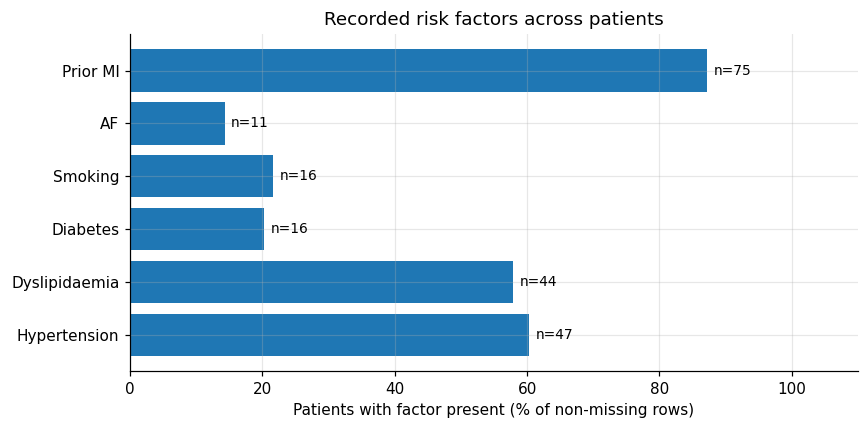


NYHA class distribution:
nyha
0         1
1        42
2        20
3         2
<NA>    108
Name: count, dtype: Int64


In [34]:
rf_cols  = [c for c in ["hta", "dlp", "dm", "smoking", "afib", "mi_yn"] if c in df.columns]
rf_pct   = df[rf_cols].apply(lambda s: (s == 1).sum() / s.notna().sum() * 100)
rf_count = df[rf_cols].apply(lambda s: (s == 1).sum())

labels_map = {"hta": "Hypertension", "dlp": "Dyslipidaemia", "dm": "Diabetes",
              "smoking": "Smoking", "afib": "AF", "mi_yn": "Prior MI"}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh([labels_map.get(c, c) for c in rf_pct.index],
               rf_pct.values, color=PAL[0])
for bar, n in zip(bars, rf_count.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"n={n}", va="center", fontsize=9)
ax.set_xlabel("Patients with factor present (% of non-missing rows)")
ax.set_xlim(0, 110)
ax.set_title("Recorded risk factors across patients")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_risk_factors.png", bbox_inches="tight")
plt.show()

# NYHA
if "nyha" in df.columns:
    print("\nNYHA class distribution:")
    print(df["nyha"].value_counts(dropna=False).sort_index())

## 4 · Scar geometry

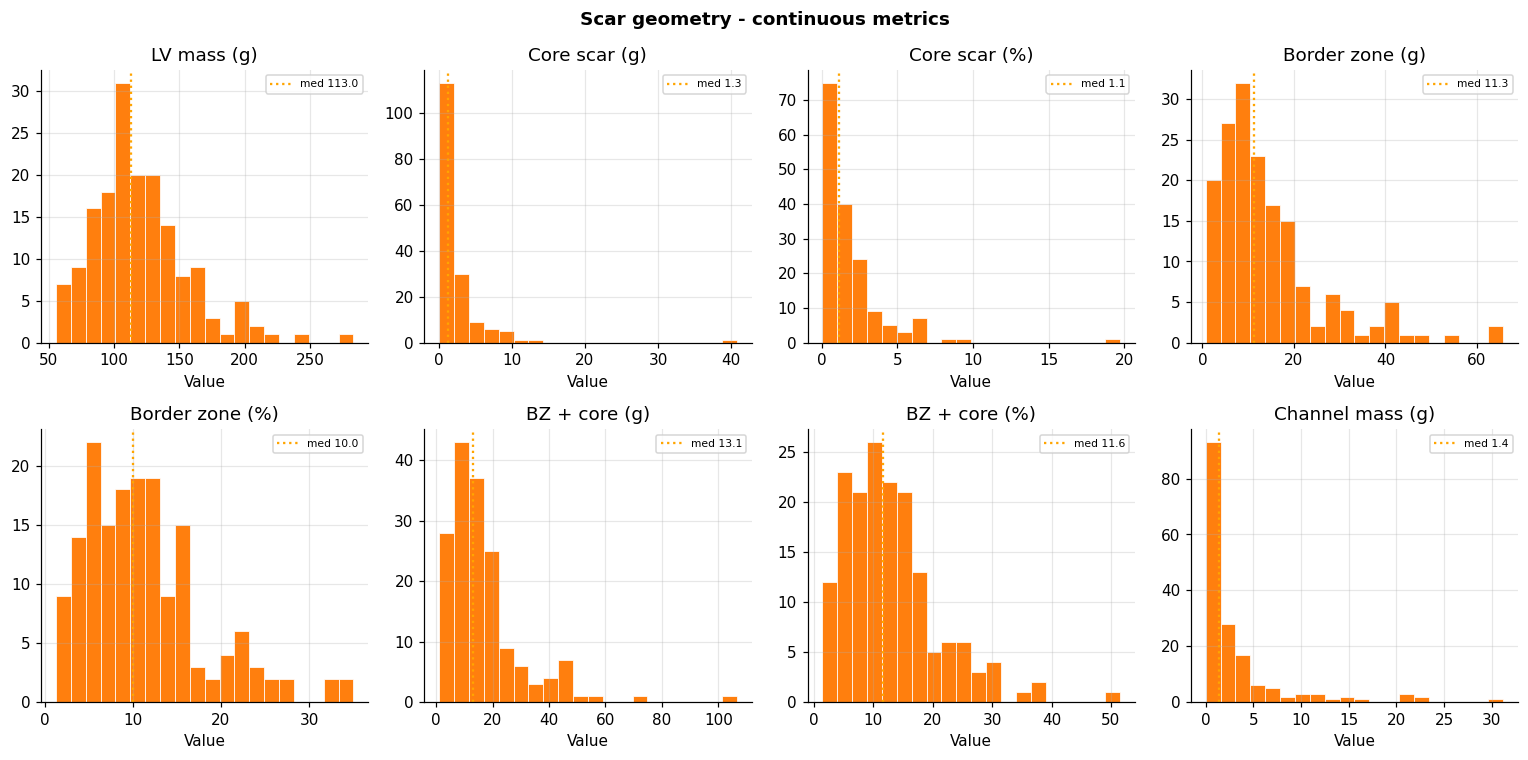

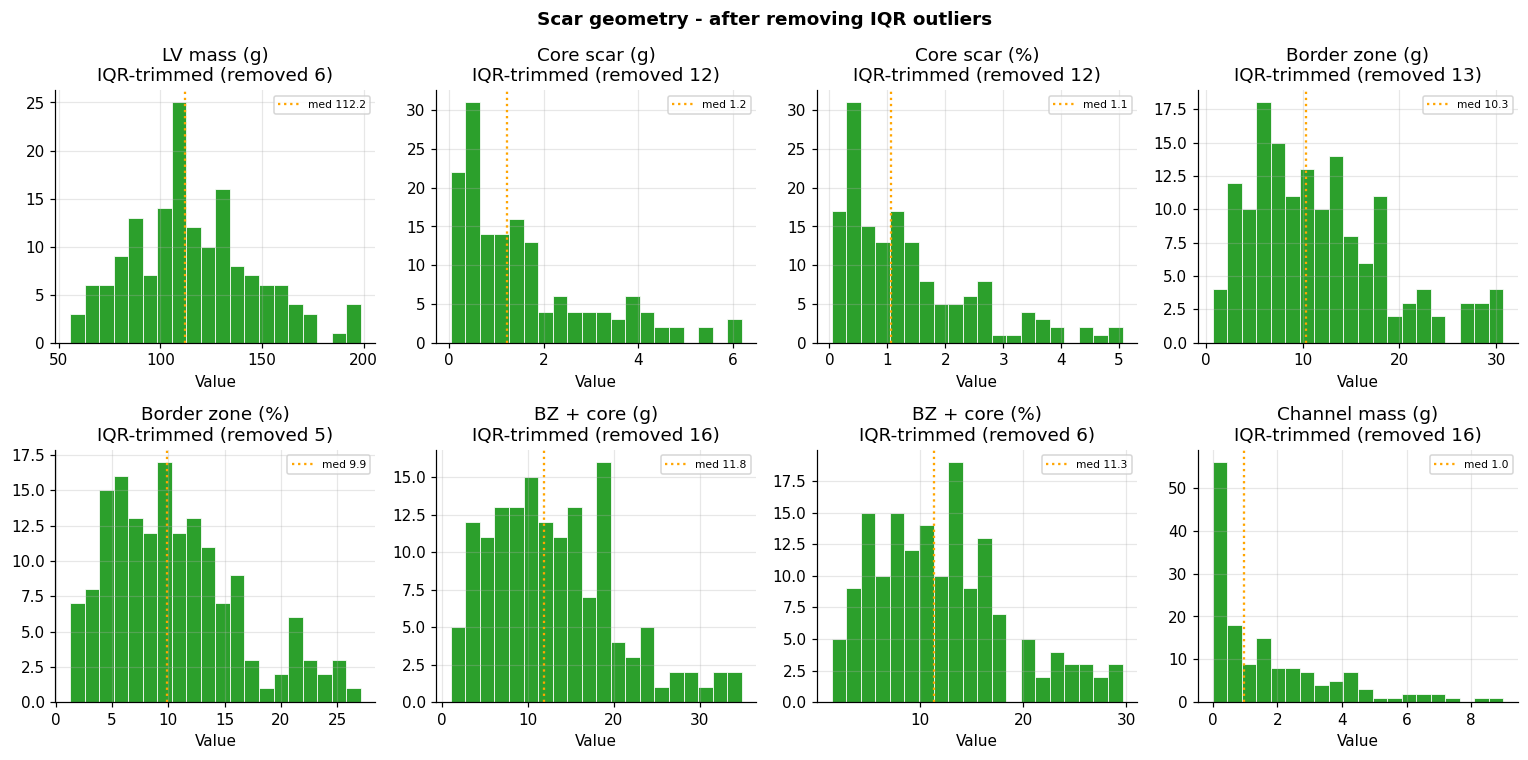


Descriptive stats:


,lv_mass_g,core_g,core_pct,bz_g,bz_pct,bz_core_g,bz_core_pct,channel_mass_g
count,166.00,166.00,166.00,166.00,166.00,166.00,166.00,167.00
mean,120.24,2.33,1.81,14.33,11.25,16.64,13.05,3.10
std,36.82,3.80,2.24,11.66,6.85,14.14,8.02,5.14
min,55.54,0.04,0.04,0.70,1.26,1.04,1.42,0.00
25%,95.20,0.55,0.47,6.58,5.93,7.93,7.49,0.00
50%,112.96,1.30,1.10,11.30,9.98,13.14,11.55,1.40
75%,137.32,2.81,2.32,17.68,14.48,19.33,16.40,3.68
max,283.25,40.76,19.71,65.73,35.04,106.50,51.50,31.20



Outlier summary (IQR rule):


,metric,n_total,n_outliers,pct_outliers
0,LV mass (g),166,6,3.6
1,Core scar (g),166,12,7.2
2,Core scar (%),166,12,7.2
3,Border zone (g),166,13,7.8
4,Border zone (%),166,5,3.0
5,BZ + core (g),166,16,9.6
6,BZ + core (%),166,6,3.6
7,Channel mass (g),167,16,9.6


In [35]:
# -- Continuous scar metrics -----------------------------------------------
scar_num = [c for c in ["lv_mass_g", "core_g", "core_pct",
                         "bz_g", "bz_pct", "bz_core_g", "bz_core_pct",
                         "channel_mass_g"] if c in df.columns]

if scar_num:
    n_cols = 4
    n_rows = int(np.ceil(len(scar_num) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
    axes = np.array(axes, dtype=object).reshape(-1)
    outlier_rows = []

    for i, col in enumerate(scar_num):
        s = df[col].dropna()
        mask = iqr_inlier_mask(s)
        s_trim = s.loc[mask]
        outlier_rows.append({
            "metric": pretty_label(col),
            "n_total": int(len(s)),
            "n_outliers": int((~mask).sum()),
            "pct_outliers": round((~mask).mean() * 100 if len(mask) else 0, 1),
        })
        axes[i].hist(s, bins=20, color=PAL[1], edgecolor="white", linewidth=0.5)
        axes[i].axvline(s.median(), color="orange", linestyle=":",
                        label=f"med {s.median():.1f}")
        axes[i].set_title(pretty_label(col))
        axes[i].set_xlabel("Value")
        axes[i].legend(fontsize=7)

    for ax in axes[len(scar_num):]:
        ax.set_visible(False)

    plt.suptitle("Scar geometry - continuous metrics", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_scar_distributions.png", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
    axes = np.array(axes, dtype=object).reshape(-1)

    for i, col in enumerate(scar_num):
        s = df[col].dropna()
        mask = iqr_inlier_mask(s)
        s_trim = s.loc[mask]
        removed = int((~mask).sum())
        axes[i].hist(s_trim, bins=20, color=PAL[2], edgecolor="white", linewidth=0.5)
        axes[i].axvline(s_trim.median(), color="orange", linestyle=":",
                        label=f"med {s_trim.median():.1f}")
        axes[i].set_title(f"{pretty_label(col)}\nIQR-trimmed (removed {removed})")
        axes[i].set_xlabel("Value")
        axes[i].legend(fontsize=7)

    for ax in axes[len(scar_num):]:
        ax.set_visible(False)

    plt.suptitle("Scar geometry - after removing IQR outliers", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_scar_distributions_trimmed.png", bbox_inches="tight")
    plt.show()

    print("\nDescriptive stats:")
    display(df[scar_num].describe().round(2))
    print("\nOutlier summary (IQR rule):")
    display(pd.DataFrame(outlier_rows))
else:
    print("No continuous scar metrics available in this registry export.")


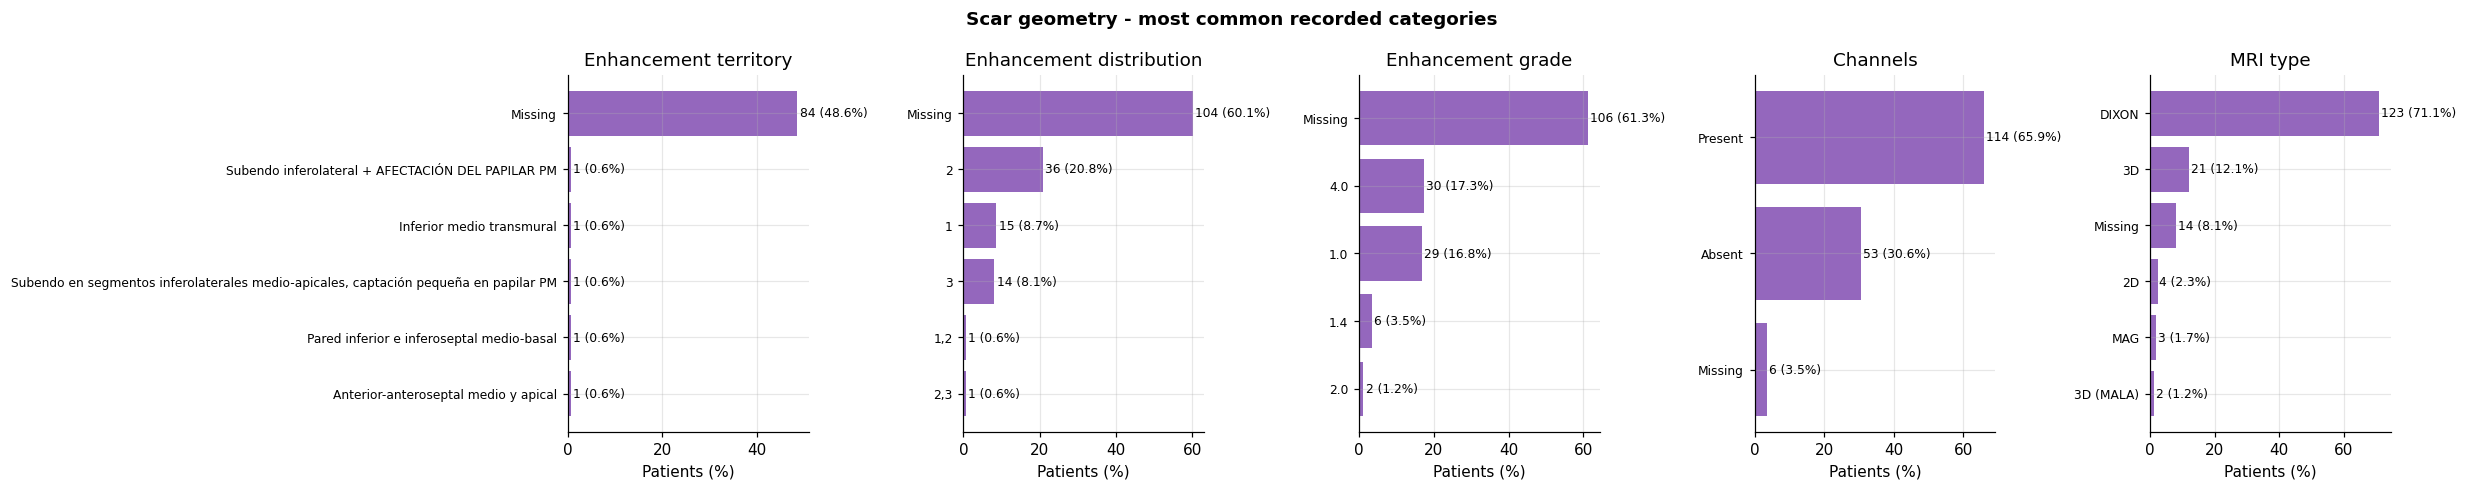

How to read these plots:
- Each panel shows the most common categories for that variable.
- Longer bars mean the category appears in more patients.
- 'Missing' means the variable was not recorded for that patient.

Main takeaways:
- Enhancement territory: most common category is Missing (n=84, 48.6% of patients).
- Enhancement distribution: most common category is Missing (n=104, 60.1% of patients).
- Enhancement grade: most common category is Missing (n=106, 61.3% of patients).
- Channels: most common category is Present (n=114, 65.9% of patients).
- MRI type: most common category is DIXON (n=123, 71.1% of patients).


In [36]:
# -- Categorical scar metrics ----------------------------------------------
cat_cols = [c for c in ["enhancement_territory", "enhancement_distribution",
                         "enhancement_grade", "channels", "mri_type"] if c in df.columns]

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(4.5 * len(cat_cols), 4.5))
    axes = np.array(axes, dtype=object).reshape(-1)
    explanations = []

    for ax, col in zip(axes, cat_cols):
        counts = (
            df[col]
            .map(lambda v: clean_category_label(col, v))
            .value_counts(dropna=False)
            .head(6)
            .sort_values(ascending=True)
        )
        pct = counts / len(df) * 100
        ax.barh(counts.index, pct.values, color=PAL[4])
        for y, (label, value) in enumerate(zip(counts.index, pct.values)):
            ax.text(value + 0.6, y, f"{counts[label]} ({value:.1f}%)", va="center", fontsize=8)
        ax.set_title(pretty_label(col))
        ax.set_xlabel("Patients (%)")
        ax.tick_params(axis="y", labelsize=8)
        top_label = counts.index[-1]
        top_count = counts.iloc[-1]
        top_pct = pct.iloc[-1]
        explanations.append(f"- {pretty_label(col)}: most common category is {top_label} (n={top_count}, {top_pct:.1f}% of patients).")

    plt.suptitle("Scar geometry - most common recorded categories", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_scar_categorical.png", bbox_inches="tight")
    plt.show()

    print("How to read these plots:")
    print("- Each panel shows the most common categories for that variable.")
    print("- Longer bars mean the category appears in more patients.")
    print("- 'Missing' means the variable was not recorded for that patient.")
    print("\nMain takeaways:")
    for msg in explanations:
        print(msg)
else:
    print("No categorical scar metrics available in this registry export.")


## 5 · Echocardiography

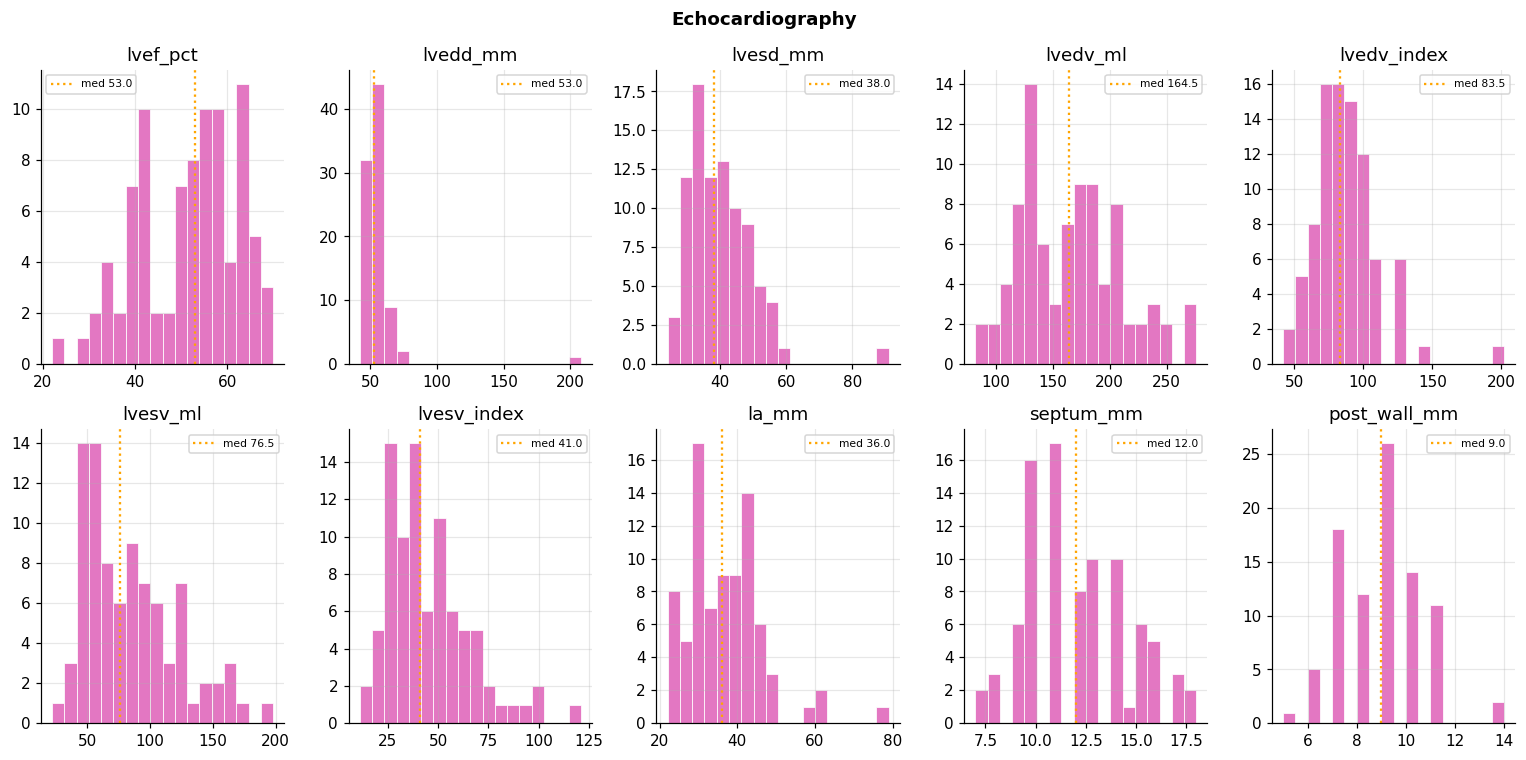

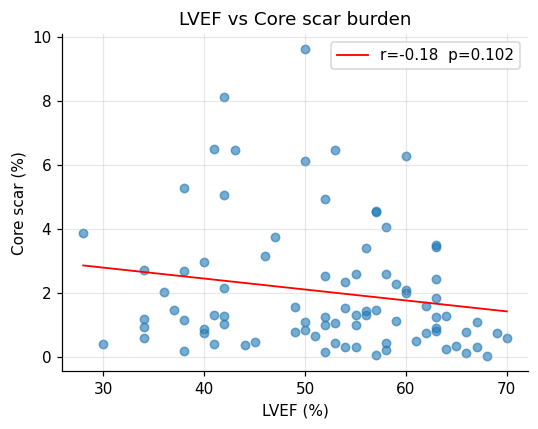

In [37]:
echo_num = [c for c in COLUMN_GROUPS["echo"] if c in df.columns]

if echo_num:
    n_cols = 5
    n_rows = int(np.ceil(len(echo_num) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
    axes = np.array(axes, dtype=object).reshape(-1)

    for i, col in enumerate(echo_num):
        s = df[col].dropna()
        axes[i].hist(s, bins=18, color=PAL[6], edgecolor="white", linewidth=0.5)
        axes[i].axvline(s.median(), color="orange", linestyle=":",
                        label=f"med {s.median():.1f}")
        axes[i].set_title(col)
        axes[i].legend(fontsize=7)

    for ax in axes[len(echo_num):]:
        ax.set_visible(False)

    plt.suptitle("Echocardiography", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_echo.png", bbox_inches="tight")
    plt.show()
else:
    print("No echocardiography variables available in this registry export.")

# LVEF vs scar burden scatter
if {"lvef_pct", "core_pct"}.issubset(df.columns) and has_valid_linear_relation_data(df, "lvef_pct", "core_pct"):
    sub = df[["lvef_pct", "core_pct"]].dropna()
    r, p = stats.pearsonr(sub["lvef_pct"], sub["core_pct"])
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(sub["lvef_pct"], sub["core_pct"], alpha=0.6, s=30, color=PAL[0])
    m, b = np.polyfit(sub["lvef_pct"], sub["core_pct"], 1)
    xs = np.linspace(sub["lvef_pct"].min(), sub["lvef_pct"].max(), 100)
    ax.plot(xs, m * xs + b, color="red", linewidth=1.2,
            label=f"r={r:.2f}  p={p:.3f}")
    ax.set_xlabel("LVEF (%)")
    ax.set_ylabel("Core scar (%)")
    ax.set_title("LVEF vs Core scar burden")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_lvef_vs_core.png", bbox_inches="tight")
    plt.show()
elif {"lvef_pct", "core_pct"}.issubset(df.columns):
    print("Skipping LVEF vs core scar plot: need at least two non-null rows with variation in both variables.")


## 6 · Correlation: demographics + risk factors × scar geometry

Variable choice for this matrix:
- clinical side: age, sex, common risk factors, NYHA, and a small set of echo variables that are clinically interpretable next to scar burden
- scar side: the main continuous scar burden measures plus two simple coded scar descriptors (`channels`, `enhancement_grade`)
- not every registry column is included, because a full all-column matrix would be dominated by missing values and text fields, and would be much harder to read

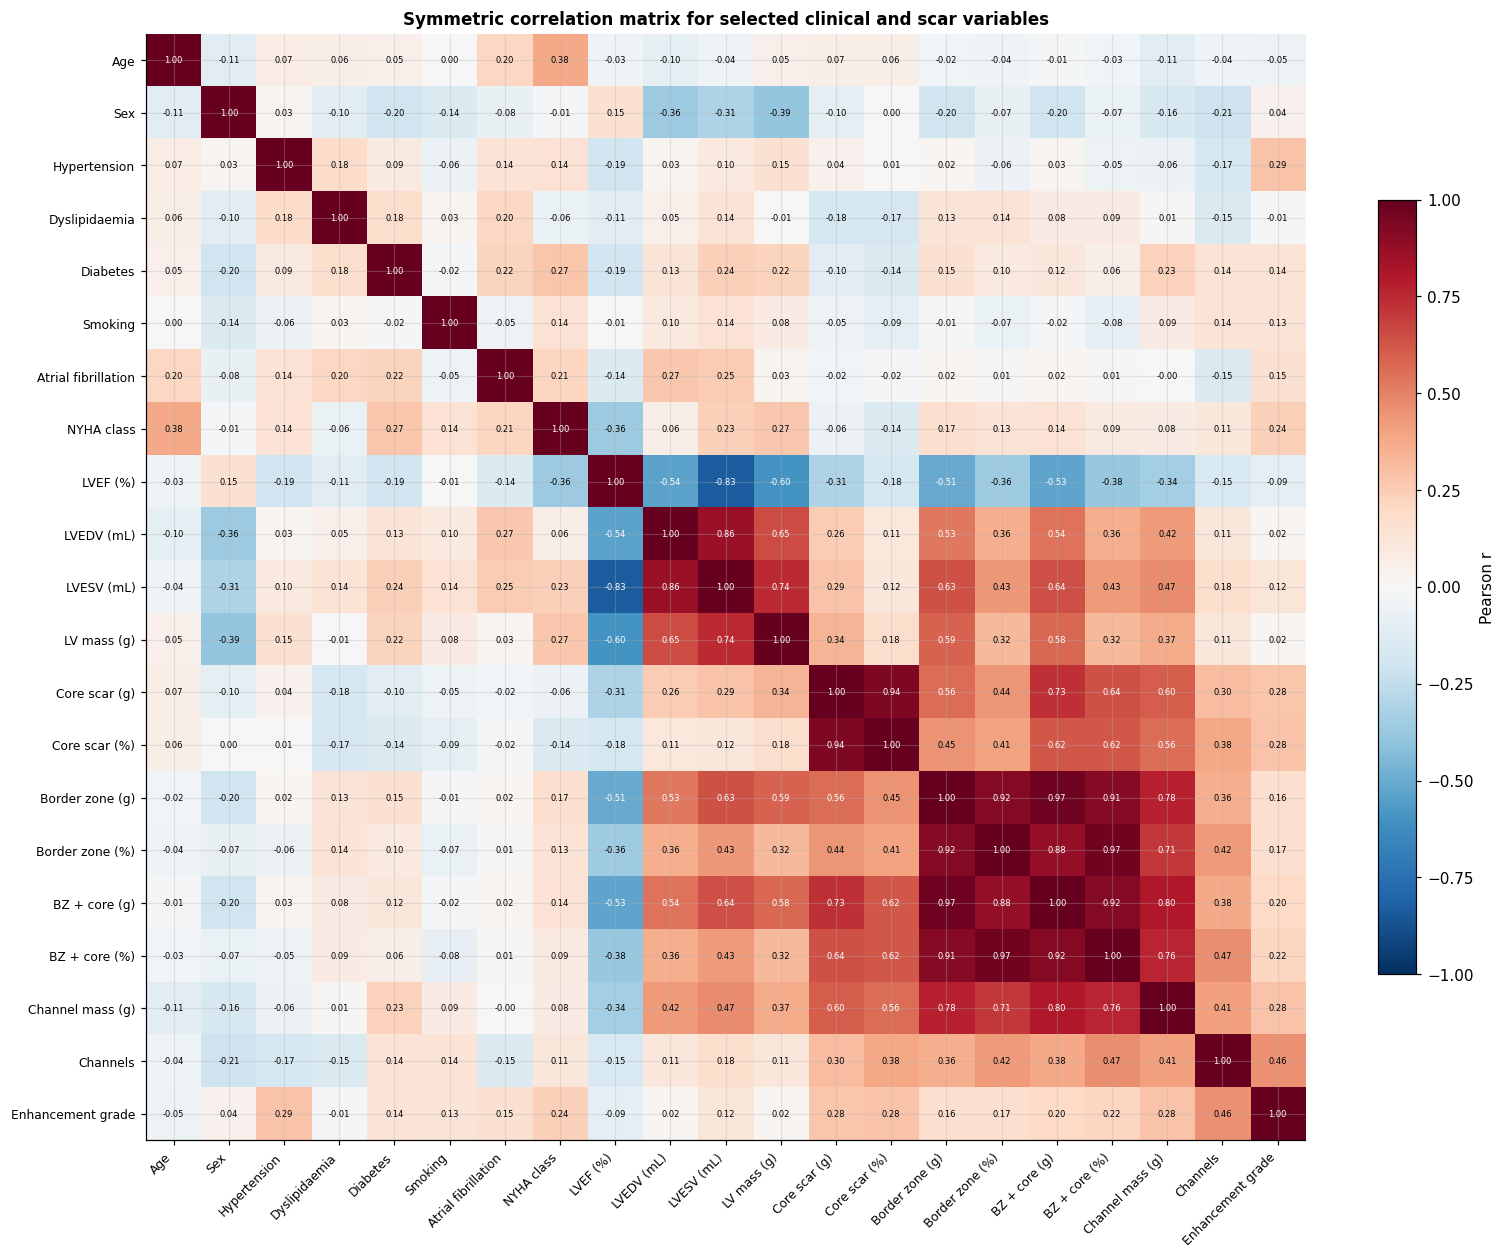

This matrix is symmetric because the same variables appear on both axes.
The earlier non-symmetric version came from plotting only the clinical × scar slice.


In [38]:
demo_rf = [c for c in
           ["age", "sex", "hta", "dlp", "dm", "smoking", "afib", "nyha",
            "lvef_pct", "lvedv_ml", "lvesv_ml"]
           if c in df.columns]

scar_vars = [c for c in
             ["lv_mass_g", "core_g", "core_pct", "bz_g", "bz_pct",
              "bz_core_g", "bz_core_pct", "channel_mass_g", "channels",
              "enhancement_grade"]
             if c in df.columns]

selected_vars = demo_rf + [c for c in scar_vars if c not in demo_rf]
corr_df = df[selected_vars].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr(method="pearson")
cross = corr.loc[demo_rf, scar_vars]

fig, ax = plt.subplots(figsize=(max(10, len(selected_vars) * 0.7),
                                max(8, len(selected_vars) * 0.55)))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(selected_vars)))
ax.set_xticklabels([pretty_label(c) for c in selected_vars], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(selected_vars)))
ax.set_yticklabels([pretty_label(c) for c in selected_vars], fontsize=8)
plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.7)

for i in range(len(selected_vars)):
    for j in range(len(selected_vars)):
        v = corr.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=5.5, color="black" if abs(v) < 0.5 else "white")

ax.set_title("Symmetric correlation matrix for selected clinical and scar variables",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("This matrix is symmetric because the same variables appear on both axes.")
print("The earlier non-symmetric version came from plotting only the clinical × scar slice.")

In [39]:
# ── Top correlations table ─────────────────────────────────────────────────
cross_flat = (
    cross.stack()
    .reset_index()
    .rename(columns={"level_0": "clinical", "level_1": "scar", 0: "r"})
)
cross_flat["abs_r"] = cross_flat["r"].abs()
print("Top 15 correlations (|r| largest):")
display(
    cross_flat.sort_values("abs_r", ascending=False)
    .head(15)
    .drop(columns="abs_r")
    .reset_index(drop=True)
)

Top 15 correlations (|r| largest):


,clinical,scar,r
0,lvesv_ml,lv_mass_g,0.742682
1,lvedv_ml,lv_mass_g,0.649962
2,lvesv_ml,bz_core_g,0.642144
3,lvesv_ml,bz_g,0.634568
4,lvef_pct,lv_mass_g,-0.600647
5,lvedv_ml,bz_core_g,0.541082
6,lvedv_ml,bz_g,0.530954
7,lvef_pct,bz_core_g,-0.529583
8,lvef_pct,bz_g,-0.507109
9,lvesv_ml,channel_mass_g,0.474875


## 7 · Subgroup box-plots

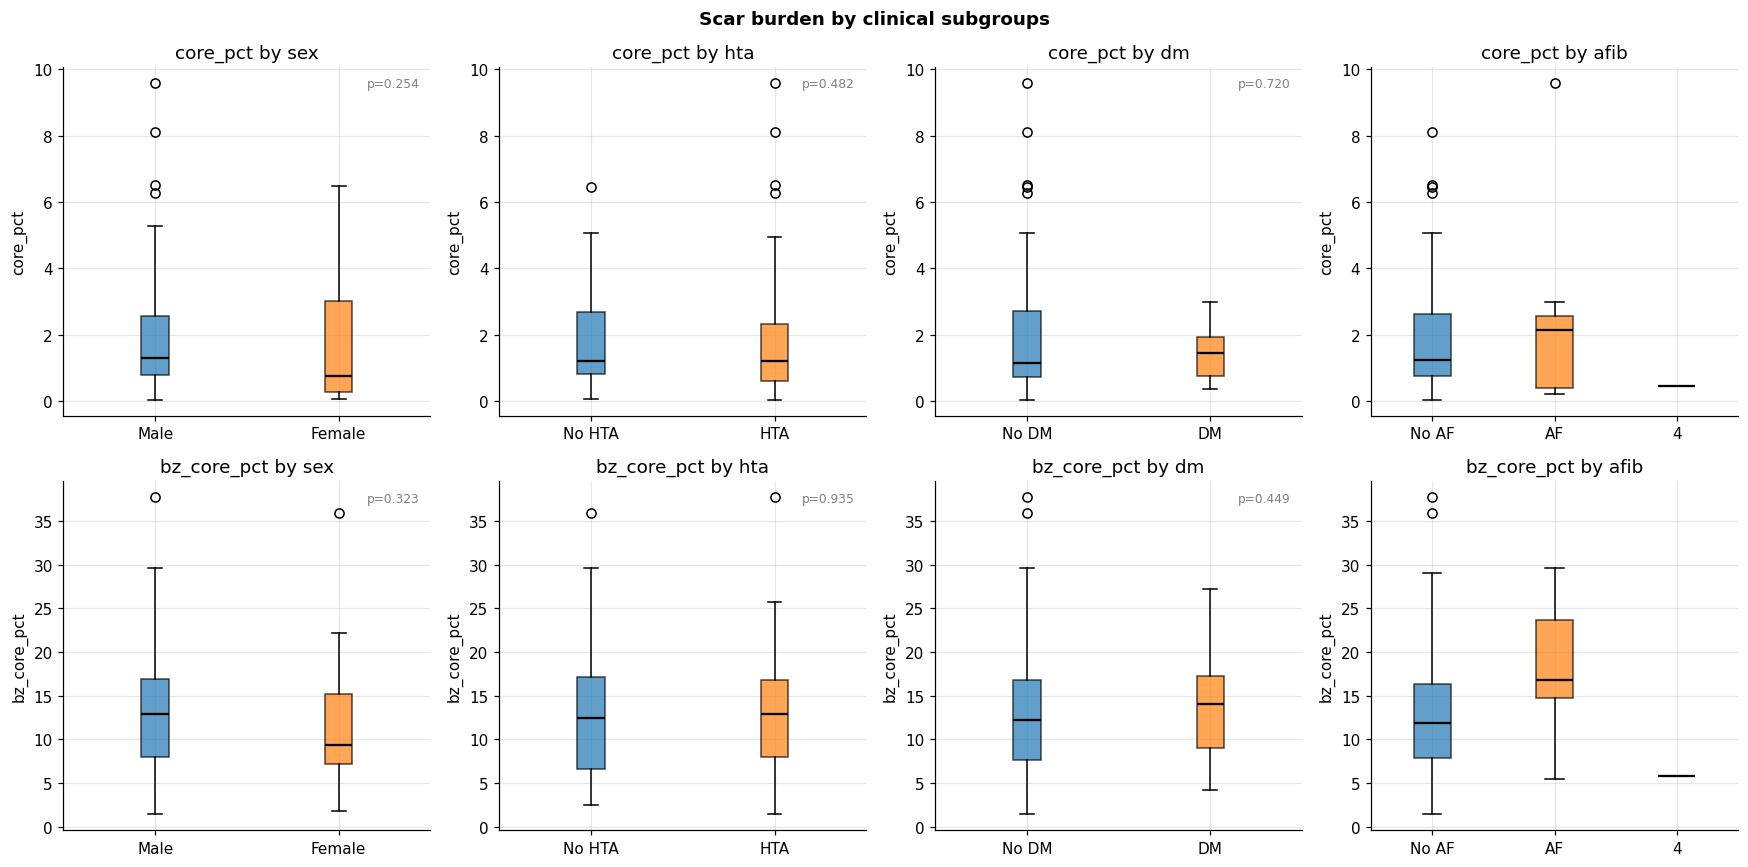

In [40]:
def boxplot_by_group(df, group_col, value_col, labels=None, title=None, ax=None):
    """Box-plot of value_col split by binary group_col, with Mann-Whitney p."""
    sub = df[[group_col, value_col]].dropna()
    groups = sorted(sub[group_col].unique())
    data   = [sub.loc[sub[group_col] == g, value_col].values for g in groups]
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    if sub.empty or len(groups) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title or f"{value_col} by {group_col}")
        return ax
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, color in zip(bp["boxes"], PAL):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    tick_labels = [labels.get(g, str(g)) if labels else str(g) for g in groups]
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel(value_col)
    ax.set_title(title or f"{value_col} by {group_col}")
    # Mann-Whitney U
    if len(data) == 2 and len(data[0]) > 0 and len(data[1]) > 0:
        u, p = stats.mannwhitneyu(data[0], data[1], alternative="two-sided")
        ax.text(0.97, 0.97, f"p={p:.3f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8,
                color="green" if p < 0.05 else "grey")
    return ax


# -- 2x4 grid: key scar metrics by sex, HTA, DM, AFIB ----------------------
scar_targets = [c for c in ["core_pct", "bz_core_pct"] if c in df.columns]
group_vars   = [c for c in ["sex", "hta", "dm", "afib"] if c in df.columns]
group_labels = {"sex": {1: "Male", 2: "Female"},
                "hta": {0: "No HTA", 1: "HTA"},
                "dm":  {0: "No DM", 1: "DM"},
                "afib": {0: "No AF", 1: "AF"}}

if scar_targets and group_vars:
    fig, axes = plt.subplots(len(scar_targets), len(group_vars),
                             figsize=(4 * len(group_vars), 4 * len(scar_targets)))
    axes = ensure_2d_axes(axes, len(scar_targets), len(group_vars))

    for row, scar in enumerate(scar_targets):
        for col, grp in enumerate(group_vars):
            boxplot_by_group(df, grp, scar,
                             labels=group_labels.get(grp, {}),
                             ax=axes[row, col])

    plt.suptitle("Scar burden by clinical subgroups", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_subgroup_boxplots.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping subgroup boxplots: need at least one scar metric and one grouping variable.")


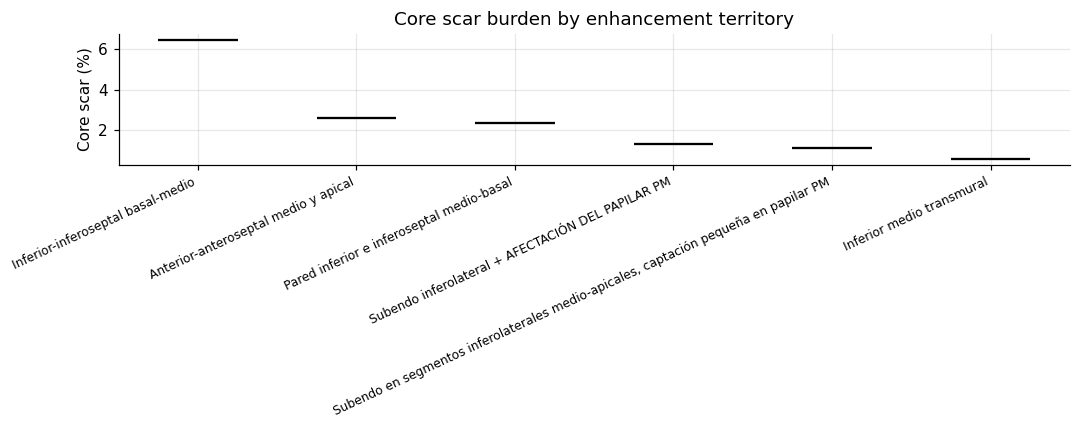

In [41]:
# ── Scar by enhancement territory (top 6 territories) ─────────────────────
if {"enhancement_territory", "core_pct"}.issubset(df.columns):
    top_terr = df["enhancement_territory"].value_counts().head(6).index
    sub = df[df["enhancement_territory"].isin(top_terr)][["enhancement_territory", "core_pct"]].dropna()

    order = sub.groupby("enhancement_territory")["core_pct"].median().sort_values(ascending=False).index
    data  = [sub.loc[sub["enhancement_territory"] == t, "core_pct"].values for t in order]

    fig, ax = plt.subplots(figsize=(10, 4))
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, color in zip(bp["boxes"], PAL):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(order, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Core scar (%)")
    ax.set_title("Core scar burden by enhancement territory")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_scar_by_territory.png", bbox_inches="tight")
    plt.show()

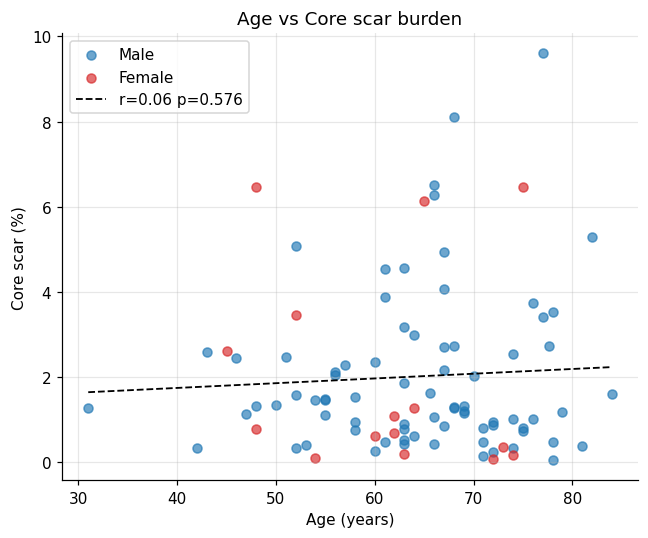

In [42]:
# -- Age vs scar burden scatter (coloured by sex) ---------------------------
if {"age", "core_pct", "sex"}.issubset(df.columns) and has_valid_linear_relation_data(df, "age", "core_pct"):
    sub = df[["age", "core_pct", "sex"]].dropna()
    fig, ax = plt.subplots(figsize=(6, 5))
    for sex_val, label, color in [(1, "Male", PAL[0]), (2, "Female", PAL[3])]:
        g = sub[sub["sex"] == sex_val]
        ax.scatter(g["age"], g["core_pct"], alpha=0.65, s=35,
                   color=color, label=label)
    # overall regression line
    m, b = np.polyfit(sub["age"], sub["core_pct"], 1)
    r, p = stats.pearsonr(sub["age"], sub["core_pct"])
    xs = np.linspace(sub["age"].min(), sub["age"].max(), 100)
    ax.plot(xs, m * xs + b, "k--", linewidth=1.2, label=f"r={r:.2f} p={p:.3f}")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Core scar (%)")
    ax.set_title("Age vs Core scar burden")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_age_vs_core.png", bbox_inches="tight")
    plt.show()
elif {"age", "core_pct", "sex"}.issubset(df.columns):
    print("Skipping age vs core scar plot: need at least two non-null rows with variation in both variables.")


## 8 · Outcomes preview

              event  n       pct
           death_yn  1  2.325581
   cardiac_death_yn  0  0.000000
arrhythmic_death_yn  0  0.000000
     followup_va_yn  0  0.000000
       admission_hf  1  2.439024
   admission_angina  7 16.666667


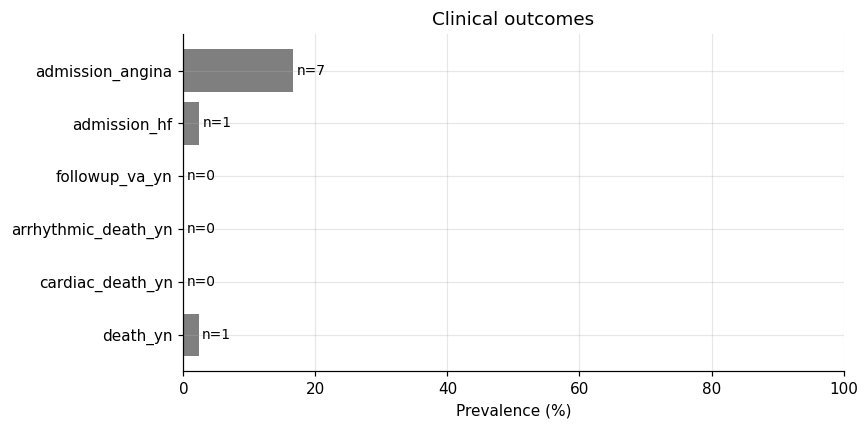

In [43]:
# ── Event rates ───────────────────────────────────────────────────────────
outcome_cols = [c for c in ["death_yn", "cardiac_death_yn", "arrhythmic_death_yn",
                              "followup_va_yn", "admission_hf", "admission_angina"]
                if c in df.columns]

if outcome_cols:
    rates = pd.DataFrame({
        "event": outcome_cols,
        "n": [int((df[c] == 1).sum()) for c in outcome_cols],
        "pct": [(df[c] == 1).sum() / df[c].notna().sum() * 100 for c in outcome_cols],
    })
    print(rates.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(rates["event"], rates["pct"], color=PAL[7])
    for i, (n, pct) in enumerate(zip(rates["n"], rates["pct"])):
        ax.text(pct + 0.5, i, f"n={n}", va="center", fontsize=9)
    ax.set_xlabel("Prevalence (%)")
    ax.set_xlim(0, 100)
    ax.set_title("Clinical outcomes")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_outcomes.png", bbox_inches="tight")
    plt.show()

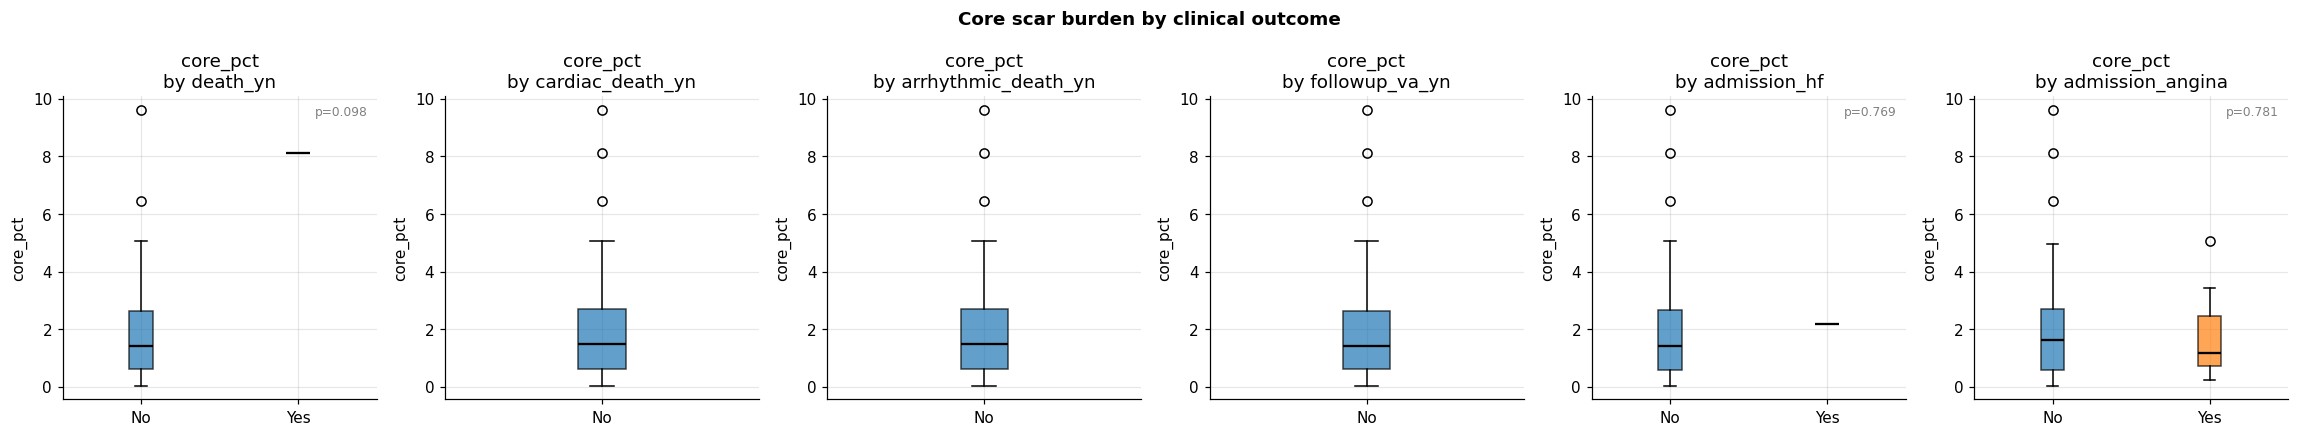

In [44]:
# ── Scar burden: event vs no-event (for each outcome) ─────────────────────
scar_metric = "core_pct" if "core_pct" in df.columns else None

if scar_metric and outcome_cols:
    fig, axes = plt.subplots(1, len(outcome_cols),
                              figsize=(3.5 * len(outcome_cols), 4))
    if len(outcome_cols) == 1:
        axes = [axes]

    for ax, oc in zip(axes, outcome_cols):
        boxplot_by_group(df, oc, scar_metric,
                         labels={0: "No", 1: "Yes"},
                         title=f"{scar_metric}\nby {oc}",
                         ax=ax)

    plt.suptitle("Core scar burden by clinical outcome", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_scar_by_outcome.png", bbox_inches="tight")
    plt.show()